# EDA - FELICIU

### TO DO:
FELICIU
    For price - right distributionm big outliers, use log transformation


KIKE

    EDA dates
    houses count (not only means) by season
    data frames filtered, cleaned, sorted, legend
 


EDA conclusions/assumptions
years built and renovated are recalculated from last date
bathrooms with decimals --> assumption '0.25 is  just to pee
zipcode/distance/lat-long evaluation -->
Seasonality --> not concluding (std of 0.5% from the mean)

In [156]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans

In [157]:
df = pd.read_csv("king_ country_ houses_aa.csv")

In [158]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [159]:
df.keys()

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [160]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [161]:
df.dtypes

id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

In [162]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [163]:
df.nunique()

id               21436
date               372
price             4028
bedrooms            13
bathrooms           30
sqft_living       1038
sqft_lot          9782
floors               6
waterfront           2
view                 5
condition            5
grade               12
sqft_above         946
sqft_basement      306
yr_built           116
yr_renovated        70
zipcode             70
lat               5034
long               752
sqft_living15      777
sqft_lot15        8689
dtype: int64

In [164]:
df.isna().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

# Data processing & cleaning

## Classification

In [165]:
target = "price"
y = df[target]

In [166]:
# id --> control digit? Correlated with date? Just random number?
# date --> date of the sale, we ensure datetime utc format. Study if there is a correlation between date and price (seasonality, trends, etc).
# zipcode --> categorical variable, we will one-hot encode it, 70 different zipcodes (adding 70 columns).

"""
lat and long --> zip code is more useful than latitude and longitude, but we can also create a new feature
with the distance to the city center (we can use the coordinates of the city center as reference) or to water bodies.
"""

cat_features = [
    "waterfront",
    "view",
    "zipcode",
    "condition",
    "grade",
    "floors",
    "bathrooms",
    "bedrooms",
]

In [167]:
# yr_built and yr_renovated --> transforming them into years since built/renovated, which will probably have a negative correlation with the price.
# yr_renovated --> 0 means never renovated, we can create a new column with a boolean value (renovated or not) as categorical variable.

num_features = [
    "sqft_living",
    "sqft_lot",
    "sqft_above",
    "sqft_basement",
    "sqft_living15",
    "sqft_lot15",
    "yr_built",
    "yr_renovated",
]

In [168]:
len(df.columns) == len(cat_features) + len(
    num_features
) + 5  # 5 columns that we are not going to use as features (id, date, lat, long, price)

True

In [169]:
df_cat = df[cat_features]

print(df_cat.nunique())

waterfront     2
view           5
zipcode       70
condition      5
grade         12
floors         6
bathrooms     30
bedrooms      13
dtype: int64


In [170]:
df_num = df[num_features]

print(df_num.describe())

        sqft_living      sqft_lot  ...      yr_built  yr_renovated
count  21613.000000  2.161300e+04  ...  21613.000000  21613.000000
mean    2079.899736  1.510697e+04  ...   1971.005136     84.402258
std      918.440897  4.142051e+04  ...     29.373411    401.679240
min      290.000000  5.200000e+02  ...   1900.000000      0.000000
25%     1427.000000  5.040000e+03  ...   1951.000000      0.000000
50%     1910.000000  7.618000e+03  ...   1975.000000      0.000000
75%     2550.000000  1.068800e+04  ...   1997.000000      0.000000
max    13540.000000  1.651359e+06  ...   2015.000000   2015.000000

[8 rows x 8 columns]


## Processing

In [171]:
df["date"] = pd.to_datetime(df["date"], utc=True)
df["date"].dtype

datetime64[ns, UTC]

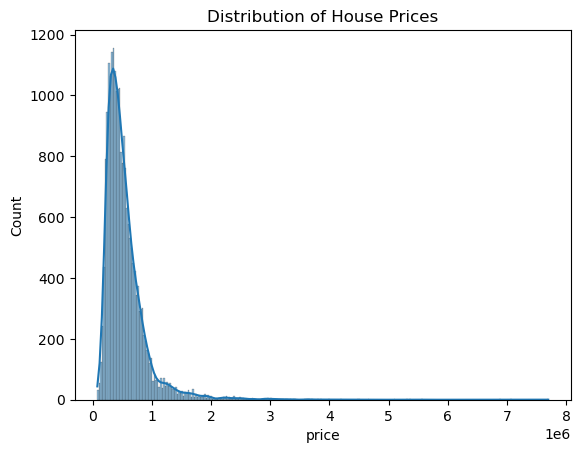

'\nIs not normal distribution is right-skewed distribution (will have to apply log transformation)\n'

In [172]:
# The PRICE distributin

sns.histplot(df["price"], kde=True)
plt.title("Distribution of House Prices")
plt.show()

"""
Is not normal distribution is right-skewed distribution (will have to apply log transformation)
"""

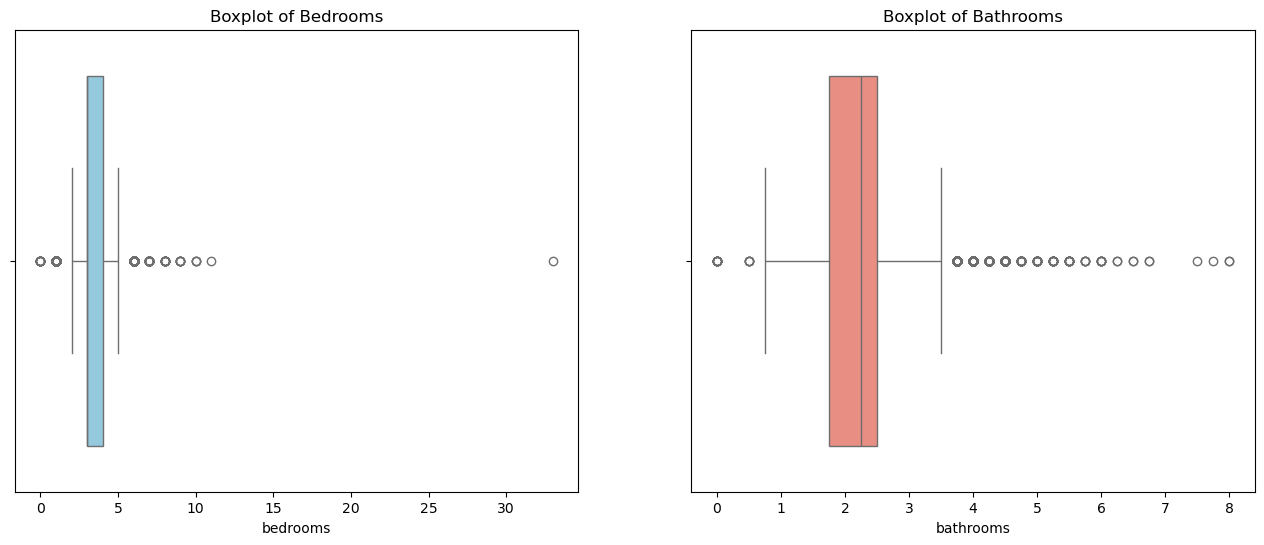

'\nOne house has 30 + bedrooms, is an outlier which has to be removed, some of them has more than 10\n'

In [173]:
plt.figure(figsize=(16, 6))

# Plot 1: Bedrooms
plt.subplot(1, 2, 1)
sns.boxplot(x=df["bedrooms"], color="skyblue")
plt.title("Boxplot of Bedrooms")

# Plot 2: Bathrooms
plt.subplot(1, 2, 2)
sns.boxplot(x=df["bathrooms"], color="salmon")
plt.title("Boxplot of Bathrooms")

plt.show()

"""
One house has 30 + bedrooms, is an outlier which has to be removed, some of them has more than 10
"""

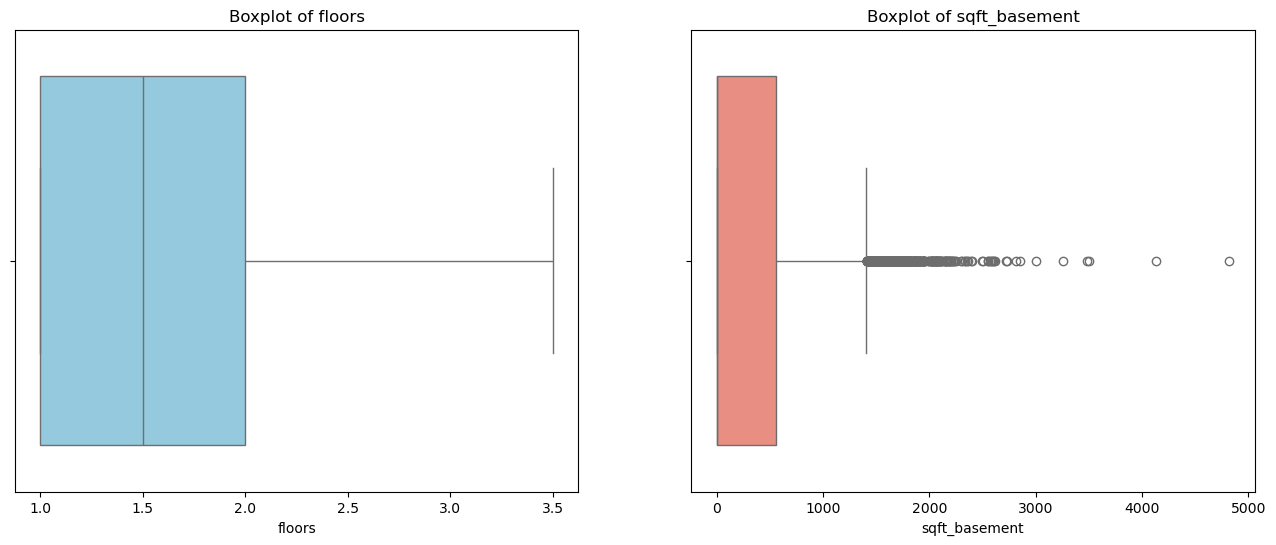

'\nBasmet square we have big numbers, couple of them are above 3000 sqft\n'

In [174]:
plt.figure(figsize=(16, 6))

# Plot 1: Foloors
plt.subplot(1, 2, 1)
sns.boxplot(x=df["floors"], color="skyblue")
plt.title("Boxplot of floors")

# Plot 2: Bathrooms
plt.subplot(1, 2, 2)
sns.boxplot(x=df["sqft_basement"], color="salmon")
plt.title("Boxplot of sqft_basement")

plt.show()

"""
Basmet square we have big numbers, couple of them are above 3000 sqft
"""

In [175]:
# Regarding the ouliers trying to see if the houses wihch got more than....5 bedroom are afecting the price, bathrooms number, sqft for: living, basement, above, lot, etc.
# Locate the extreme outlier
extreme_bedrooms = df[df["bedrooms"] >= 10]
print("Houses with more than 10 bedrooms:")
print(
    extreme_bedrooms[
        [
            "price",
            "bedrooms",
            "bathrooms",
            "sqft_living",
            "sqft_lot",
            "sqft_above",
            "sqft_basement",
            "floors",
        ]
    ]
)

Houses with more than 10 bedrooms:
           price  bedrooms  bathrooms  ...  sqft_above  sqft_basement  floors
8757    520000.0        11       3.00  ...        2400            600     2.0
13314  1148000.0        10       5.25  ...        2500           2090     1.0
15161   650000.0        10       2.00  ...        3010            600     2.0
15870   640000.0        33       1.75  ...        1040            580     1.0
19254   660000.0        10       3.00  ...        1860           1060     2.0

[5 rows x 8 columns]


In [176]:
df_cleaned = df[df["bedrooms"] < 10]

# For better representation of the price distribution, we can apply a logarithmic transformation to the price variable. This can help to reduce the skewness and make the distribution more normal, which is often beneficial for modeling purposes.
df_cleaned["price_log"] = np.log(df_cleaned["price"])

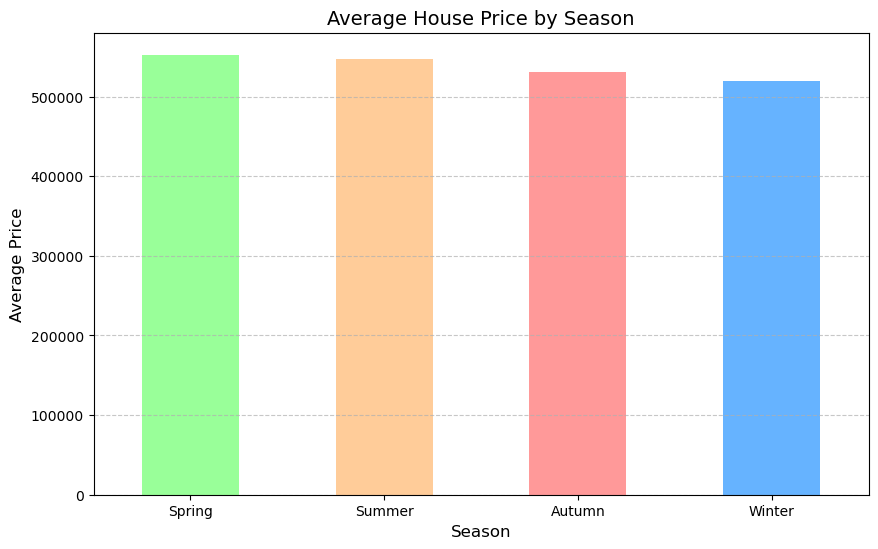

Average Spring Price: $552,603.24
Average Winter Price: $519,183.17
---
Difference: $33,420.08
Percentage Increase in Spring: 6.44%


'\nThere is just a small difference of 6.44% between selling the house in winter and selling the house in spring\n'

In [177]:
# 1. Ensure the column is a proper datetime object
df_cleaned["date"] = pd.to_datetime(df["date"])

# 2. Strip the Time (Keep only Year-Month-Day)
df_cleaned["date_only"] = df_cleaned["date"].dt.date


# 3. Create a 'Season' column based on the month
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"


df_cleaned["season"] = df_cleaned["date"].dt.month.apply(get_season)


# Calculate average price per season
seasonal_data = (
    df_cleaned.groupby("season")["price"].mean().reindex(["Spring", "Summer", "Autumn", "Winter"])
)

# Plotting
plt.figure(figsize=(10, 6))
seasonal_data.plot(kind="bar", color=["#99ff99", "#ffcc99", "#ff9999", "#66b3ff"])

plt.title("Average House Price by Season", fontsize=14)
plt.xlabel("Season", fontsize=12)
plt.ylabel("Average Price", fontsize=12)
plt.xticks(rotation=0)  # Keeps the labels horizontal
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

# 1. Calculate the average price for each season
avg_prices = df_cleaned.groupby("season")["price"].mean()

spring_price = avg_prices["Spring"]
winter_price = avg_prices["Winter"]

# 2. Calculate the differences
price_diff = spring_price - winter_price
percentage_diff = (price_diff / winter_price) * 100

print(f"Average Spring Price: ${spring_price:,.2f}")
print(f"Average Winter Price: ${winter_price:,.2f}")
print(f"---")
print(f"Difference: ${price_diff:,.2f}")
print(f"Percentage Increase in Spring: {percentage_diff:.2f}%")

"""
There is just a small difference of 6.44% between selling the house in winter and selling the house in spring
"""

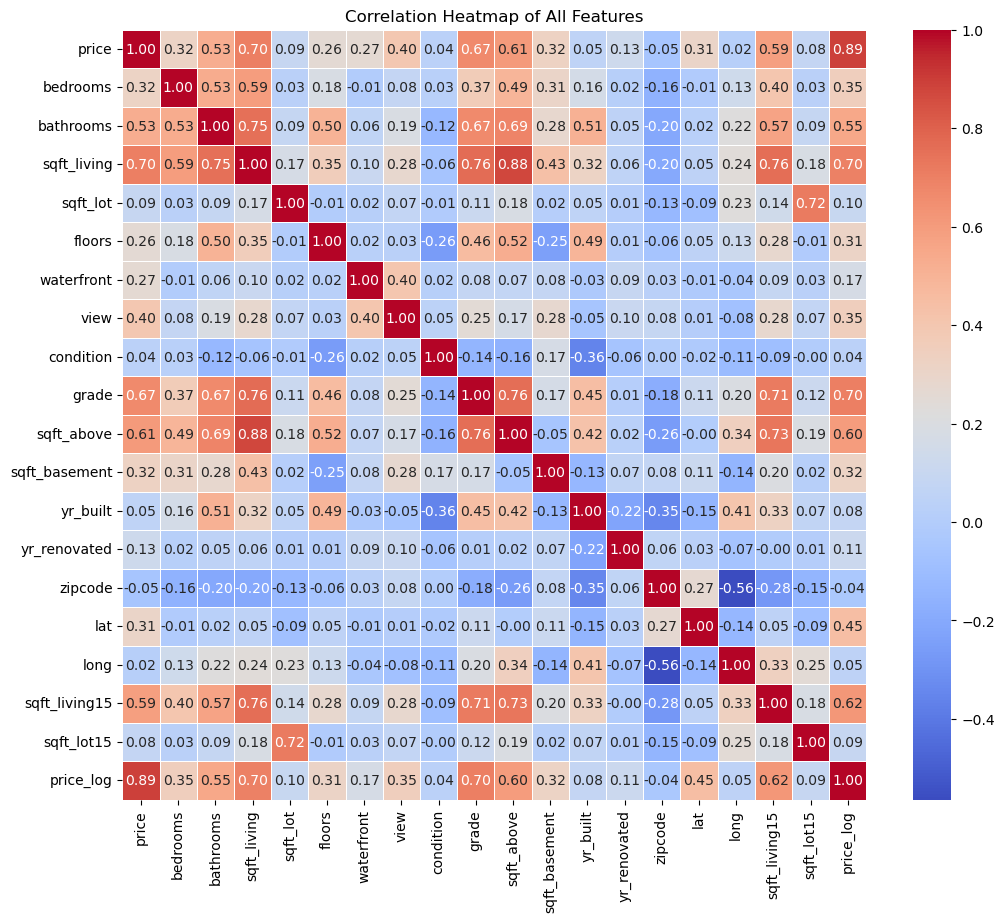

In [178]:
# 1. Calculate the correlation matrix
# We use .select_dtypes('number') to ignore text/date columns
df_cleaned = df_cleaned.drop("id", axis=1, errors="ignore")
corr_matrix = df_cleaned.select_dtypes("number").corr()

# 2. Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# 3. Create the heatmap
sns.heatmap(
    corr_matrix,
    annot=True,  # Show the numeric values in the cells
    fmt=".2f",  # Round to 2 decimal places
    cmap="coolwarm",  # Red for positive, Blue for negative
    linewidths=0.5,
)

plt.title("Correlation Heatmap of All Features")
plt.show()

##### KEEP:
    sqft_living (0.70): The strongest physical predictor.
    grade (0.67): High-quality construction significantly bumps price.
    bathrooms (0.53): A reliable indicator of house size/luxury.
    view (0.40): A good secondary indicator of value.
#### SOMETHING INTRESTING:
    yr_built (0.05): The raw year doesn't correlate well because an old house could be a "historic gem" or a "fixer-upper."
    yr_renovated (0.13): Most values are zero.
    Recommendation: Instead of dropping them, combine them! Create an age feature (2026 - yr_built) and an is_renovated (1 or 0) feature.

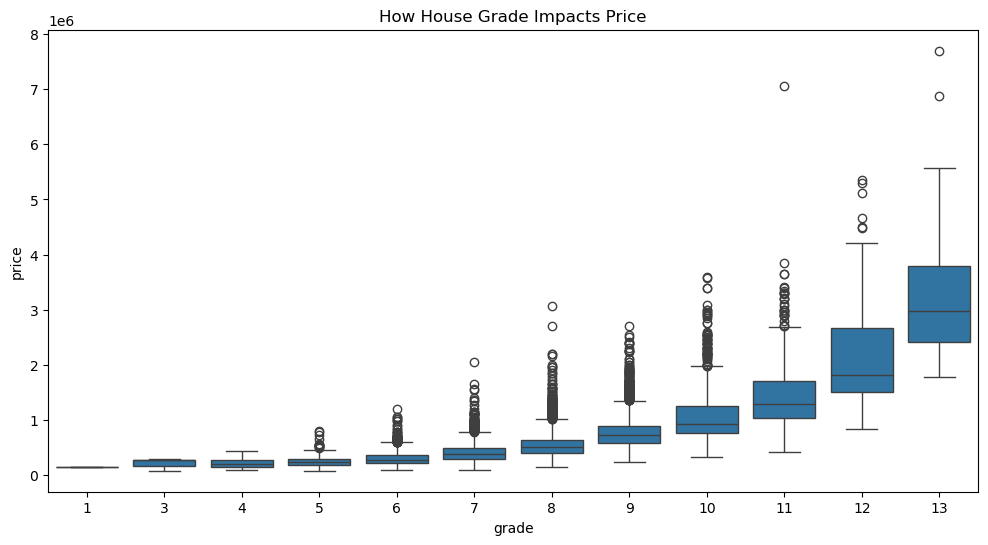

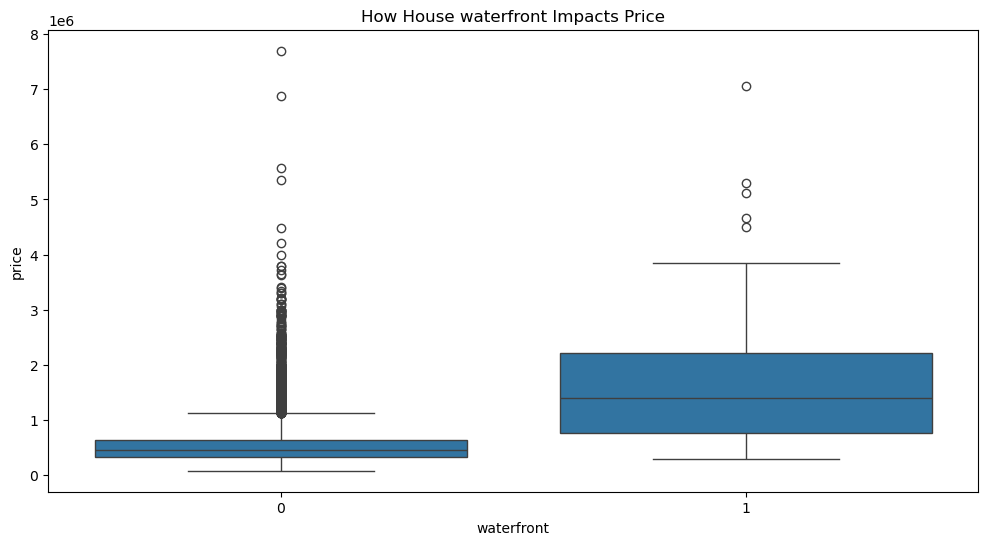

"\nHow House Grade Impacts Price:\nExponential Growth: Price doesn't just increase linearly with grade—it curves upward. Moving from a Grade 7 to a Grade 8 \nhas a smaller price jump than moving from Grade 11 to Grade 12.\n\nHow Waterfront Impacts Price:\nThe median price for waterfront (1) homes is significantly higher than the highest non-outlier prices for standard homes.\nEven without a waterfront view (the 0 category), there are many homes in the $3M–$7M range. \nThis suggests that while waterfront is a huge boost, location/size can still drive prices to the extreme on their own.\n\n"

In [179]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="grade", y="price", data=df)
plt.title("How House Grade Impacts Price")
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x="waterfront", y="price", data=df)
plt.title("How House waterfront Impacts Price")
plt.show()
"""
How House Grade Impacts Price:
Exponential Growth: Price doesn't just increase linearly with grade—it curves upward. Moving from a Grade 7 to a Grade 8 
has a smaller price jump than moving from Grade 11 to Grade 12.

How Waterfront Impacts Price:
The median price for waterfront (1) homes is significantly higher than the highest non-outlier prices for standard homes.
Even without a waterfront view (the 0 category), there are many homes in the $3M–$7M range. 
This suggests that while waterfront is a huge boost, location/size can still drive prices to the extreme on their own.

"""

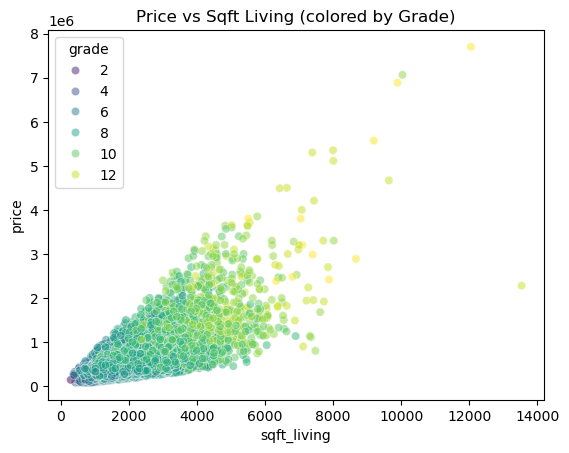

In [180]:
# Check how living space relates to grade and price simultaneously
sns.scatterplot(data=df, x="sqft_living", y="price", hue="grade", palette="viridis", alpha=0.5)
plt.title("Price vs Sqft Living (colored by Grade)")
plt.show()

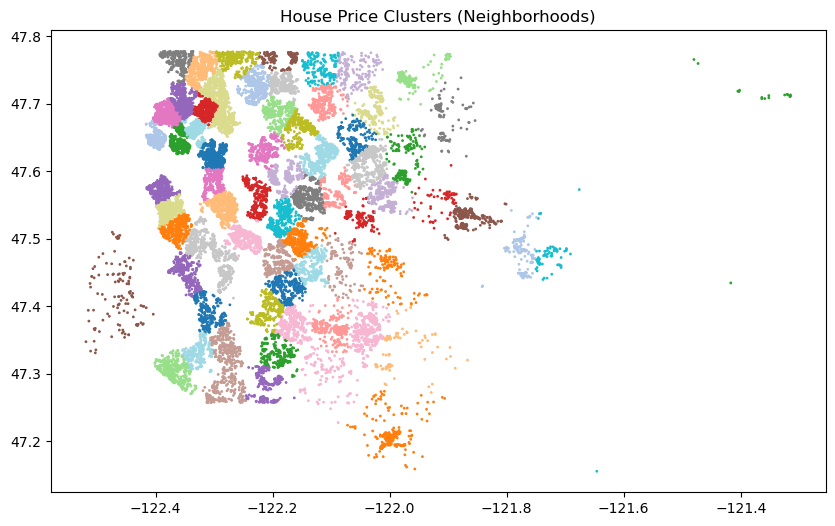

In [181]:
"""
Regarding the lat and long, we can take the Seattle city center and calculate the distance for each house based on distance we can calcualte the price
For new created column "neighborhood_group" use Random Forest / XGBoost
"""

# Coordinates of the city center (example: Seattle)
center_lat, center_long = 47.62, -122.33

# Simple Euclidean distance (works for small city areas)
df_cleaned["dist_to_center"] = np.sqrt(
    (df_cleaned["lat"] - center_lat) ** 2 + (df_cleaned["long"] - center_long) ** 2
)

# Create 70 "price neighborhoods" based on location. We will compare with the zipcodes.
price_neighborhoods_number = 70
coords = df_cleaned[["lat", "long"]]
# 2. Create 70 clusters (representing 70 logical neighborhoods)
kmeans = KMeans(n_clusters=price_neighborhoods_number, random_state=13)
df_cleaned["neighborhood_group"] = kmeans.fit_predict(coords)


# 3. Visualize the clusters to see the "Zones"
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(
    df_cleaned["long"], df_cleaned["lat"], c=df_cleaned["neighborhood_group"], cmap="tab20", s=1
)
plt.title("House Price Clusters (Neighborhoods)")
plt.show()

In [182]:
"""import geopandas as gpd
import contextily as ctx

# 1. Create GeoDataFrame from lat/long
gdf = gpd.GeoDataFrame(
    df_cleaned.copy(),
    geometry=gpd.points_from_xy(df_cleaned["long"], df_cleaned["lat"]),
    crs="EPSG:4326",
)

# 2. Convert to Web Mercator projection (needed for the basemap)
gdf = gdf.to_crs(epsg=3857)

# 3. Plot points + map
fig, ax = plt.subplots(figsize=(12, 10))

gdf.plot(ax=ax, column="neighborhood_group", cmap="tab20", markersize=8, alpha=0.7, legend=False)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

ax.set_title("House Price Clusters on Map", fontsize=16)
ax.set_axis_off()

plt.show()"""

'import geopandas as gpd\nimport contextily as ctx\n\n# 1. Create GeoDataFrame from lat/long\ngdf = gpd.GeoDataFrame(\n    df_cleaned.copy(),\n    geometry=gpd.points_from_xy(df_cleaned["long"], df_cleaned["lat"]),\n    crs="EPSG:4326",\n)\n\n# 2. Convert to Web Mercator projection (needed for the basemap)\ngdf = gdf.to_crs(epsg=3857)\n\n# 3. Plot points + map\nfig, ax = plt.subplots(figsize=(12, 10))\n\ngdf.plot(ax=ax, column="neighborhood_group", cmap="tab20", markersize=8, alpha=0.7, legend=False)\n\nctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)\n\nax.set_title("House Price Clusters on Map", fontsize=16)\nax.set_axis_off()\n\nplt.show()'

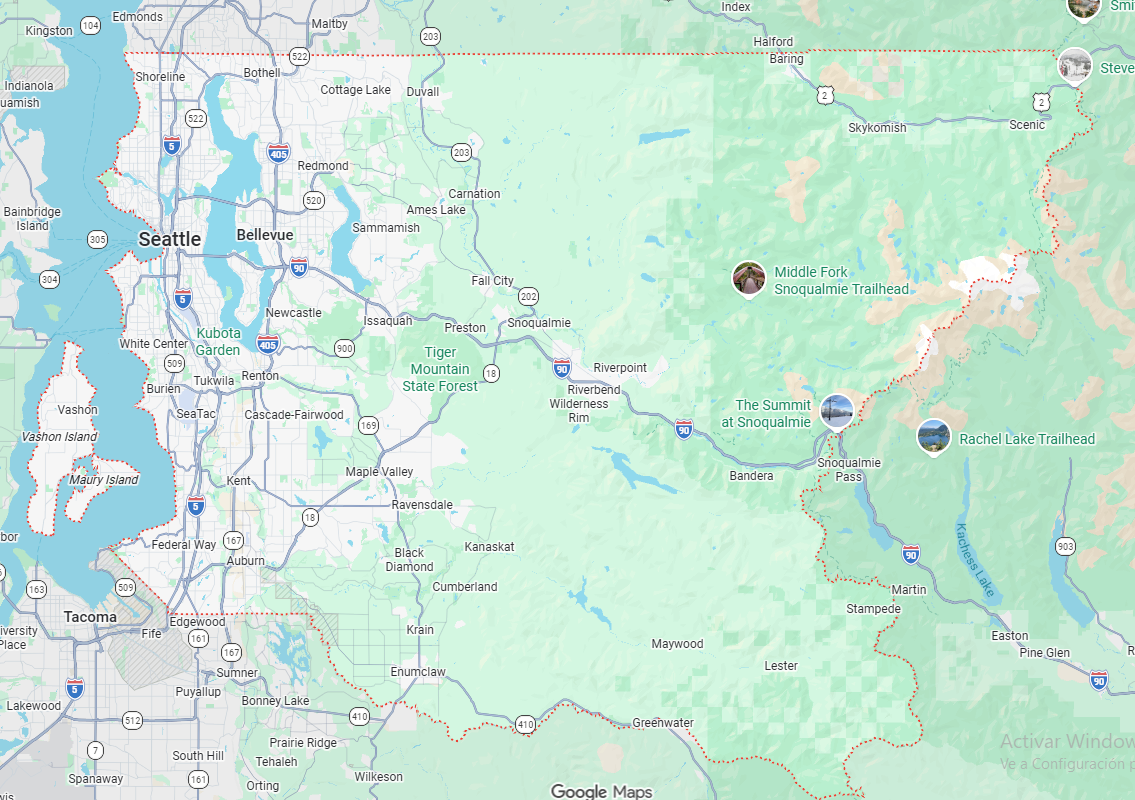

In [183]:
df["zipcode"].value_counts()

zipcode
98103    602
98038    590
98115    583
98052    574
98117    553
        ... 
98102    105
98010    100
98024     81
98148     57
98039     50
Name: count, Length: 70, dtype: int64

In [184]:
# Study the purity of the clusters in terms of zipcodes, to see if the clusters are capturing the geographical information well.
# Using it as another form of correlation between the clusters and the zipcodes.
pd.crosstab(df_cleaned["zipcode"], df_cleaned["neighborhood_group"])

ct = pd.crosstab(df_cleaned["zipcode"], df_cleaned["neighborhood_group"])
purity_by_zipcode = ct.max(axis=1) / ct.sum(axis=1)
purity_by_zipcode.sort_values(ascending=False)

""" The average purity score (~0.72) indicates that zipcode partially aligns with geographic clusters,
 but does not fully capture the underlying spatial structure. KMeans clustering reveals intra-zipcode 
 variation that is lost when using zipcode as a feature. """

print(round(purity_by_zipcode.mean(), 2))

0.72


In [185]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# -----------------------------------
# 1. Ensure correct data types
# -----------------------------------
df_compare = df_cleaned.copy()

df_compare["zipcode"] = df_compare["zipcode"].astype(str)
df_compare["neighborhood_group"] = df_compare["neighborhood_group"].astype(str)

y = df_compare["price"]

# -----------------------------------
# 2. Dataset using only ZIPCODE
# -----------------------------------
X_zip = pd.get_dummies(df_compare[["zipcode"]], drop_first=True)

X_train_zip, X_test_zip, y_train, y_test = train_test_split(
    X_zip, y, test_size=0.2, random_state=42
)

model_zip = LinearRegression()
model_zip.fit(X_train_zip, y_train)

y_pred_zip = model_zip.predict(X_test_zip)

r2_zip = r2_score(y_test, y_pred_zip)
rmse_zip = np.sqrt(mean_squared_error(y_test, y_pred_zip))

# -----------------------------------
# 3. Dataset using only GEO CLUSTERS
# -----------------------------------
X_geo = pd.get_dummies(df_compare[["neighborhood_group"]], drop_first=True)

X_train_geo, X_test_geo, y_train, y_test = train_test_split(
    X_geo, y, test_size=0.2, random_state=42
)

model_geo = LinearRegression()
model_geo.fit(X_train_geo, y_train)

y_pred_geo = model_geo.predict(X_test_geo)

r2_geo = r2_score(y_test, y_pred_geo)
rmse_geo = np.sqrt(mean_squared_error(y_test, y_pred_geo))

# -----------------------------------
# 4. Comparison
# -----------------------------------
results = pd.DataFrame(
    {"model": ["zipcode", "geo_cluster"], "R2": [r2_zip, r2_geo], "RMSE": [rmse_zip, rmse_geo]}
)

print(results)

         model        R2           RMSE
0      zipcode  0.390842  299986.539109
1  geo_cluster  0.359268  307662.825327


In [186]:
"""# GEOSPACIAL PRICE MAP

# Create GeoDataFrame from lat/long
gdf = gpd.GeoDataFrame(
    df_cleaned.copy(),
    geometry=gpd.points_from_xy(df_cleaned["long"], df_cleaned["lat"]),
    crs="EPSG:4326",
)

# Convert to Web Mercator projection for basemap
gdf = gdf.to_crs(epsg=3857)

# Plot points colored by log(price) for better representation of skewed distribution
fig, ax = plt.subplots(figsize=(12, 10))

gdf.plot(
    ax=ax,
    column="price_log",
    cmap="viridis",
    markersize=8,
    alpha=0.7,
    legend=True,
    vmin=df_cleaned["price_log"].min(),
    vmax=df_cleaned["price_log"].max(),
)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

ax.set_title("Log House Prices on Map", fontsize=16)
ax.set_axis_off()

plt.show()"""

'# GEOSPACIAL PRICE MAP\n\n# Create GeoDataFrame from lat/long\ngdf = gpd.GeoDataFrame(\n    df_cleaned.copy(),\n    geometry=gpd.points_from_xy(df_cleaned["long"], df_cleaned["lat"]),\n    crs="EPSG:4326",\n)\n\n# Convert to Web Mercator projection for basemap\ngdf = gdf.to_crs(epsg=3857)\n\n# Plot points colored by log(price) for better representation of skewed distribution\nfig, ax = plt.subplots(figsize=(12, 10))\n\ngdf.plot(\n    ax=ax,\n    column="price_log",\n    cmap="viridis",\n    markersize=8,\n    alpha=0.7,\n    legend=True,\n    vmin=df_cleaned["price_log"].min(),\n    vmax=df_cleaned["price_log"].max(),\n)\n\nctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)\n\nax.set_title("Log House Prices on Map", fontsize=16)\nax.set_axis_off()\n\nplt.show()'

In [187]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

X = df_cleaned[["lat", "long"]]
y = df_cleaned["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("R2 lat/long RF:", r2_score(y_test, y_pred))

R2 lat/long RF: 0.5833040661124538


In [188]:
# One-Hot Encoding the yr_renovated (1 -> YES and 0 -> NO)
df_cleaned["is_renovated"] = df_cleaned["yr_renovated"].apply(lambda x: 1 if x > 0 else 0)

In [189]:
# Calculating the age of the houses, dates when it was sold - date of built
df_cleaned["house_age"] = df_cleaned["date"].dt.year - df_cleaned["yr_built"]
df_cleaned["house_age_renovated"] = df_cleaned["date"].dt.year - df_cleaned["yr_renovated"]

In [190]:
# One-Hot Encoding the zipcode
df_cleaned = pd.get_dummies(df_cleaned, columns=["zipcode"])

In [191]:
# linear correlation between price and date (year)
df_cleaned["price"].corr((df_cleaned["date"]).dt.year)

np.float64(0.0036563843877994353)

In [192]:
df_cleaned["sqft_price"] = df_cleaned["price"] / df_cleaned["sqft_living"]

# We get the mean of the price per square foot to have a better understanding of the price distribution and to be able to compare it with other houses in the same area or with similar characteristics.
df_cleaned["sqft_price"].mean()

np.float64(264.1610455723079)

In [193]:
df_cleaned.drop(columns=["yr_built", "yr_renovated", "date_only"], inplace=True)

In [194]:
df_cleaned.keys()

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'lat', 'long', 'sqft_living15', 'sqft_lot15',
       'price_log', 'season', 'dist_to_center', 'neighborhood_group',
       'is_renovated', 'house_age', 'house_age_renovated', 'zipcode_98001',
       'zipcode_98002', 'zipcode_98003', 'zipcode_98004', 'zipcode_98005',
       'zipcode_98006', 'zipcode_98007', 'zipcode_98008', 'zipcode_98010',
       'zipcode_98011', 'zipcode_98014', 'zipcode_98019', 'zipcode_98022',
       'zipcode_98023', 'zipcode_98024', 'zipcode_98027', 'zipcode_98028',
       'zipcode_98029', 'zipcode_98030', 'zipcode_98031', 'zipcode_98032',
       'zipcode_98033', 'zipcode_98034', 'zipcode_98038', 'zipcode_98039',
       'zipcode_98040', 'zipcode_98042', 'zipcode_98045', 'zipcode_98052',
       'zipcode_98053', 'zipcode_98055', 'zipcode_98056', 'zipcode_98058',
       'zipcode_98059', 'zipcode_

# HAPPY MONKEY MODELLING

In [195]:
dropped_columns = ["date", "price", "season", "neighborhood_group", "dist_to_center"]

In [196]:
df_model = df_cleaned.drop(columns=dropped_columns)
df_model = df_model.drop(columns=df_model.columns[df_model.columns.str.contains("zip")])
print(df_model.keys())

target = df_model["price_log"]
target2 = df_model["sqft_price"]

df_model.drop(columns="price_log", inplace=True)
df_model.drop(columns="sqft_price", inplace=True)

Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'lat', 'long', 'sqft_living15', 'sqft_lot15',
       'price_log', 'is_renovated', 'house_age', 'house_age_renovated',
       'sqft_price'],
      dtype='object')


In [ ]:
num_features = [
    "bedrooms",
    "bathrooms",
    "sqft_living",
    "sqft_lot",
    "floors",
    "sqft_above",
    "sqft_basement",
    "lat",
    "long",
    "sqft_living15",
    "sqft_lot15",
    "house_age",
    "house_age_renovated",
]
cat_features = ["waterfront", "view", "condition", "grade", "is_renovated"]

df_model_cat = df_model.drop(columns=num_features)
df_model_num = df_model[num_features]

In [198]:
df_model_cat.keys()

Index(['waterfront', 'view', 'condition', 'grade', 'is_renovated'], dtype='object')

In [199]:
len(df_model_cat.keys()) == len(cat_features)

True

ENSEMBLE MODELS (If I'm not ending in five minutes .... just wait longer)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    mean_squared_error,
    mean_absolute_percentage_error,
    classification_report,
    accuracy_score,
)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [201]:
# Split or spit the data, no comming back from this.

X = df_model
y = target  # Going just with price_log (Kiiiikkkeeeeee will go with target2 = "sqft_price")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)

print(f"Training shapes: {X_train.shape}, {y_train.shape}")
print(f"Testing shapes: {X_test.shape}, {y_test.shape}")

Training shapes: (17286, 18), (17286,)
Testing shapes: (4322, 18), (4322,)


In [ ]:
# Random forest regresson (BEAT THIS MDFK)
model_base_rf = RandomForestRegressor(random_state=7)
model_base_rf.fit(X_train, y_train)

y_pred_log_test = model_base_rf.predict(X_test)
y_pred_log_train = model_base_rf.predict(X_train)

# MSE
# Have to go back to dollars for MAE or we will get thery small results.....
y_test_dollars = np.exp(y_test)
y_pred_test_dollars = np.exp(y_pred_log_test)

mape_test = mean_absolute_percentage_error(y_test_dollars, y_pred_test_dollars)
accuracy_percentage = (1 - mape_test) * 100

# RMSE (Root Mean Squared Error)
mse_test = mean_squared_error(y_test_dollars, y_pred_test_dollars)
rmse_test = np.sqrt(mse_test)

# MAPE (Mean Absolute Percentage Error)
mape_test = mean_absolute_percentage_error(y_test_dollars, y_pred_test_dollars)

print("--- Random Forest Performance ---")
print(f"R2 Score test: {r2_score(y_test, y_pred_log_test):.4f}")
print(f"R2 Score train: {r2_score(y_train, y_pred_log_train):.4f}")
print(f"Mean Prediction Accuracy: {accuracy_percentage:.2f}%")
print(f"Average Error test (MAE): ${mean_absolute_error(y_test_dollars, y_pred_test_dollars):,.2f}")
print(f"RMSE test: ${rmse_test:,.2f}")
print(f"MAPE test: {mape_test:.2%}")
""" 
Parkour......
The model is high-performing with a score of R2 0.98 that currently is overfitting the training data, as de difference between 0.98 and 0.88 is more that 1% 

ERRORS:
MAE test 72k ->on avg the prediction is off by about 72k.
RMSE test 135k -> nearly double the MAE, means RMSE heavily penalizes big mistakes, the that that is mouch higher that MAE means the data has big outliers.
MAPE test 12.77% -> means that the model is within 12.77% of the actual price, which is maybe okay with bigh house prices but is very bad for houses around 400k and lower.
"""

--- Random Forest Performance ---
R2 Score test: 0.8876
R2 Score train: 0.9837
Mean Prediction Accuracy: 87.23%
Average Error test (MAE): $72,423.69
RMSE test: $135,592.65
MAPE test: 12.77%


' \nParkour......\nThe model is high-performing with a score of R2 0.98 that currently is overfitting the training data, as de difference between 0.98 and 0.88 is more that 1% \n\nERRORS:\nMAE test 72k ->on avg the prediction is off by about 72k.\nRMSE test 135k -> nearly double the MAE, means RMSE heavily penalizes big mistakes, the that that is mouch higher that MAE means the data has big outliers.\nMAPE test 12.77% -> means that the model is within 12.77% of the actual price, which is maybe okay with bigh house prices but is very bad for houses around 400k and lower.\n'

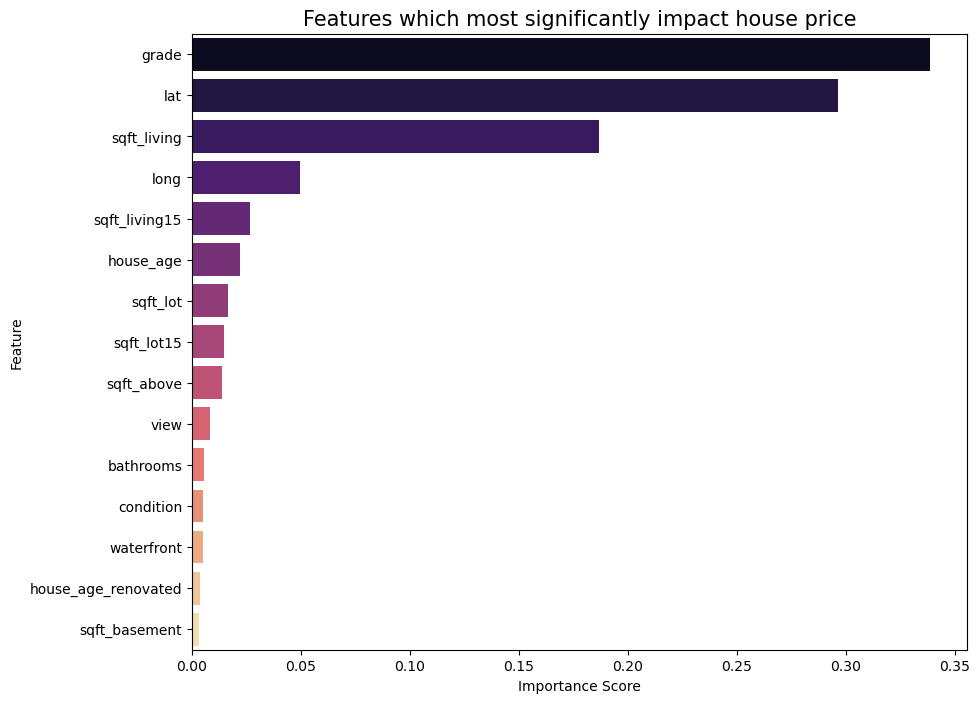

'\nGrade: the value multiplier -> this is the cunstruction quality, high grade are pushing the price higher.\nLat: the location achor -> the location is on second place which is dictaiting the price\nsqft_living: the overall sqft is on the third place.\n\n'

In [ ]:
# 1. Extract importances from the model
importances = model_base_rf.feature_importances_
feature_names = X_train.columns

# 2. Create a DataFrame for easy plotting
feature_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
feature_df = feature_df.sort_values(by="Importance", ascending=False)

# 3. Plot the top 15 features
plt.figure(figsize=(10, 8))
sns.barplot(x="Importance", y="Feature", data=feature_df.head(15), palette="magma")
plt.title("Features which most significantly impact house price", fontsize=15)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

"""
Grade: the value multiplier -> this is the cunstruction quality, high grade are pushing the price higher. 33-34%
Lat: the location achor -> the location is on second place which is dictaiting the price 29%
sqft_living: the overall sqft is on the third place. 17%

"""

In [ ]:
# 1. Initialize with "Anti-Overfitting" settings
model_gb = GradientBoostingRegressor(
    n_estimators=500,  # More trees, but smaller steps
    learning_rate=0.05,  # Slows down learning to prevent memorization
    max_depth=4,  # Limits tree complexity
    subsample=0.8,  # Uses 80% of data per tree (adds randomness)
    random_state=7,
)

# 2. Fit on the log-transformed target
model_gb.fit(X_train, y_train)

# 3. Predictions (Log Space)
y_pred_log_test = model_gb.fit(X_train, y_train).predict(X_test)
y_pred_log_train = model_gb.predict(X_train)

# 4. Convert to Dollars for final report
y_test_dlr = np.exp(y_test)
y_pred_dlr = np.exp(y_pred_log_test)

# 5. Results
print(f"--- Gradient Boosting Performance ---")
print(f"R2 Score (Test):  {r2_score(y_test, y_pred_log_test):.4f}")
print(f"R2 Score (Train): {r2_score(y_train, y_pred_log_train):.4f}")
print(f"MAE:              ${mean_absolute_error(y_test_dlr, y_pred_dlr):,.2f}")
print(f"RMSE:             ${np.sqrt(mean_squared_error(y_test_dlr, y_pred_dlr)):,.2f}")
print(f"MAPE:             {mean_absolute_percentage_error(y_test_dlr, y_pred_dlr):.2%}")

""" 
Parkour......Parkour
The model is high-performing with a score of R2 0.92 which is doing better slighty worst than random forest, but the gap between the Train and Test is jsut 3% (0.92 nad 0.89)
so this model performed better.

ERRORS:
MAE test 69k ->on avg the prediction is off by about 69k.
RMSE test 127k -> nearly double the MAE, means RMSE heavily penalizes big mistakes, the that that is mouch higher that MAE means the data has big outliers.
MAPE test 12.37% -> means that the model is within 12.37% of the actual price, which is maybe okay with bigh house prices but is very bad for houses around 400k and lower.

Interpretation: Gradient Boosting is not just a little better; it specifically reduced the RMSE significantly.
This means it is doing a much better job of handling those expensive $650K+ homes that were causing the Random Forest to trip up.
"""

--- Gradient Boosting Performance ---
R2 Score (Test):  0.8987
R2 Score (Train): 0.9277
MAE:              $69,102.65
RMSE:             $127,092.09
MAPE:             12.37%


' \nParkour......Parkour\nThe model is high-performing with a score of R2 0.92 which is doing better slighty worst than random forest, but the gap between the Train and Test is jsut 3% (0.92 nad 0.89)\nso this model performed better.\n\nERRORS:\nMAE test 69k ->on avg the prediction is off by about 69k.\nRMSE test 127k -> nearly double the MAE, means RMSE heavily penalizes big mistakes, the that that is mouch higher that MAE means the data has big outliers.\nMAPE test 12.37% -> means that the model is within 12.37% of the actual price, which is maybe okay with bigh house prices but is very bad for houses around 400k and lower.\n\nInterpretation: Gradient Boosting is not just a little better; it specifically reduced the RMSE significantly.\nThis means it is doing a much better job of handling those expensive $650K+ homes that were causing the Random Forest to trip up.\n'

# ABOVE 650k

In [ ]:
# Create a dataset for house above $650K
df_luxury = df_cleaned[df_cleaned["price"] >= 650000].copy()
print("\n--- Luxury Segment Stats ---")
print(f"{round(df_luxury[['price', 'grade', 'sqft_living']].describe(),2)}")
df_luxury["price_log"] = np.log(df_luxury["price"])
target_luxury = df_luxury["price_log"]
dropped_columns = [
    "date",
    "price",
    "season",
    "neighborhood_group",
    "dist_to_center",
    "price_log",
    "sqft_lot15",
    "sqft_living15",
    "is_renovated",
    "sqft_price",
]
df_luxury = df_luxury.drop(columns=dropped_columns)
df_luxury = df_luxury.drop(columns=df_luxury.columns[df_luxury.columns.str.contains("zip")])
# Check the size
print(f"Total houses in dataset: {len(df_cleaned)}")
print(f"Houses above $650K:      {len(df_luxury)}")
print(f"Percentage of market:    {(len(df_luxury)/len(df_cleaned)):.2%}")


--- Luxury Segment Stats ---
            price    grade  sqft_living
count     5321.00  5321.00      5321.00
mean    990758.49     8.85      3004.80
std     477830.85     1.23      1028.67
min     650000.00     5.00       890.00
25%     725000.00     8.00      2330.00
50%     830000.00     9.00      2890.00
75%    1050000.00    10.00      3510.00
max    7700000.00    13.00     13540.00
Total houses in dataset: 21608
Houses above $650K:      5321
Percentage of market:    24.63%


In [217]:
# Split or spit the data, no comming back from this. (Again this stupid joke?)

X = df_luxury
y = target_luxury  # Going just with price_log (Kiiiikkkeeeeee will go with target2 = "sqft_price") -> Not sure about this anymore 😭

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)

print(f"Training shapes: {X_train.shape}, {y_train.shape}")
print(f"Testing shapes: {X_test.shape}, {y_test.shape}")

Training shapes: (4256, 15), (4256,)
Testing shapes: (1065, 15), (1065,)


In [ ]:
# Random forest regresson (BEAT THIS MDFK)
model_base_rf = RandomForestRegressor(random_state=7)
model_base_rf.fit(X_train, y_train)

y_pred_log_test = model_base_rf.predict(X_test)
y_pred_log_train = model_base_rf.predict(X_train)

# MSE
# Have to go back to dollars for MAE or we will get thery small results.....
y_test_dollars = np.exp(y_test)
y_pred_test_dollars = np.exp(y_pred_log_test)

mape_test = mean_absolute_percentage_error(y_test_dollars, y_pred_test_dollars)
accuracy_percentage = (1 - mape_test) * 100

# RMSE (Root Mean Squared Error)
mse_test = mean_squared_error(y_test_dollars, y_pred_test_dollars)
rmse_test = np.sqrt(mse_test)

# MAPE (Mean Absolute Percentage Error)
mape_test = mean_absolute_percentage_error(y_test_dollars, y_pred_test_dollars)

print("--- Random Forest Performance ---")
print(f"R2 Score test: {r2_score(y_test, y_pred_log_test):.4f}")
print(f"R2 Score train: {r2_score(y_train, y_pred_log_train):.4f}")
print(f"Mean Prediction Accuracy: {accuracy_percentage:.2f}%")
print(f"Average Error test (MAE): ${mean_absolute_error(y_test_dollars, y_pred_test_dollars):,.2f}")
print(f"RMSE test: ${rmse_test:,.2f}")
print(f"MAPE test: {mape_test:.2%}")

--- Random Forest Performance ---
R2 Score test: 0.7685
R2 Score train: 0.9707
Mean Prediction Accuracy: 88.42%
Average Error test (MAE): $129,852.39
RMSE test: $220,383.38
MAPE test: 11.58%


In [ ]:
# 1. Initialize with "Anti-Overfitting" settings
model_gb = GradientBoostingRegressor(
    n_estimators=500,  # More trees, but smaller steps
    learning_rate=0.05,  # Slows down learning to prevent memorization
    max_depth=4,  # Limits tree complexity
    subsample=0.8,  # Uses 80% of data per tree (adds randomness)
    random_state=7,
)

# 2. Fit on the log-transformed target
model_gb.fit(X_train, y_train)

# 3. Predictions (Log Space)
y_pred_log_test = model_gb.fit(X_train, y_train).predict(X_test)
y_pred_log_train = model_gb.predict(X_train)

# 4. Convert to Dollars for final report
y_test_dlr = np.exp(y_test)
y_pred_dlr = np.exp(y_pred_log_test)

# 5. Results
print(f"--- Gradient Boosting Performance ---")
print(f"R2 Score (Test):  {r2_score(y_test, y_pred_log_test):.4f}")
print(f"R2 Score (Train): {r2_score(y_train, y_pred_log_train):.4f}")
print(f"MAE:              ${mean_absolute_error(y_test_dlr, y_pred_dlr):,.2f}")
print(f"RMSE:             ${np.sqrt(mean_squared_error(y_test_dlr, y_pred_dlr)):,.2f}")
print(f"MAPE:             {mean_absolute_percentage_error(y_test_dlr, y_pred_dlr):.2%}")

--- Gradient Boosting Performance ---
R2 Score (Test):  0.8125
R2 Score (Train): 0.9280
MAE:              $114,870.66
RMSE:             $181,451.66
MAPE:             10.69%


Conclusion: 
In the luxury segment ($650K+), Gradient Boosting outperformed Random Forest by providing a more stable prediction with an average accuracy of 89.31%. Crucially, it reduced the Root Mean Squared Error by nearly $40,000, demonstrating superior performance in handling high-value outliers.

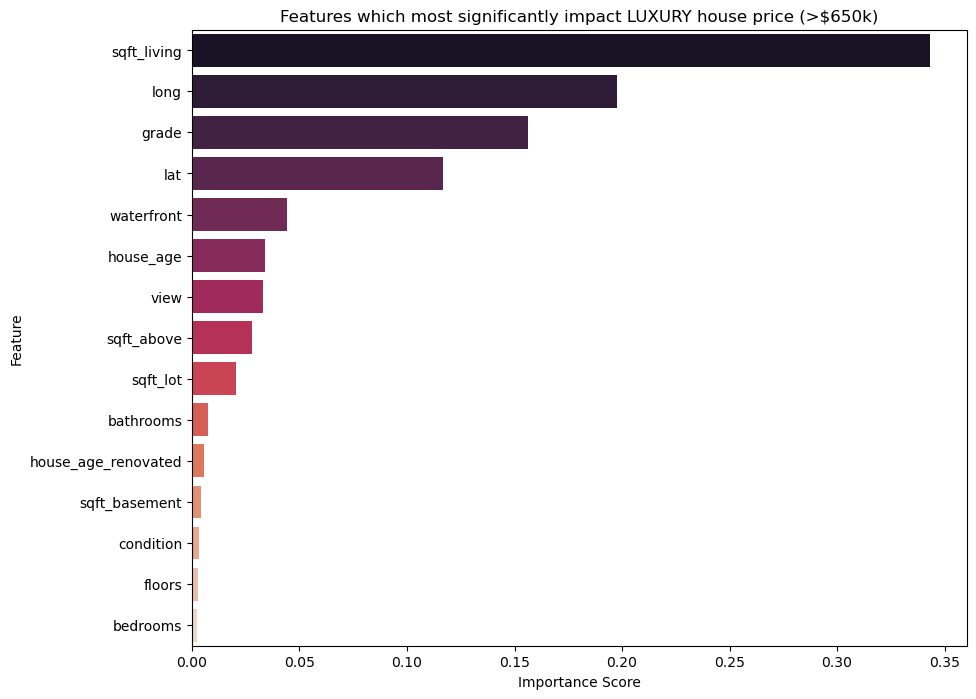

In [ ]:
# 1. Prepare X features and y target for the LUXURY model
# We must use 'price_log' so the model focuses on percentage error!
X_luxury = df_luxury
y_luxury = target_luxury

# 2. Retrain the model ONLY on the luxury subset
model_luxury_gb = GradientBoostingRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=4, random_state=7
)
model_luxury_gb.fit(X_luxury, y_luxury)

# 3. Extract, Sort, and Visualize Importance Scores
# Get the raw scores from the model
importances_lux = model_luxury_gb.feature_importances_
feature_names_lux = X_luxury.columns

# Create the visualization (identical style to your chart)
plt.figure(figsize=(10, 8))
sns.barplot(
    x=importances_lux,
    y=feature_names_lux,
    palette="rocket",
    order=X_luxury.columns[importances_lux.argsort()[::-1]],
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Features which most significantly impact LUXURY house price (>$650k)")
plt.show()

"""
For the houses above 650k - aka luxury, the price is inflenced by sqft by aprox 34%, next one is the position with 29%, grade 16%
"""